In [1]:
import pandas as pd

# Carregando os dados da pasta anterior (../ volta uma pasta)
caminho_arquivo = '../data/ai4i2020.csv'
df = pd.read_csv(caminho_arquivo)

# Exibindo as 5 primeiras linhas da tabela e as informações das colunas
display(df.head())
print("\n--- Informações do Dataset ---")
df.info()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int6

Valores nulos por coluna:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


C:\Users\Sidimar Lucato\AppData\Local\Temp\ipykernel_11588\2433164623.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df, palette='viridis')


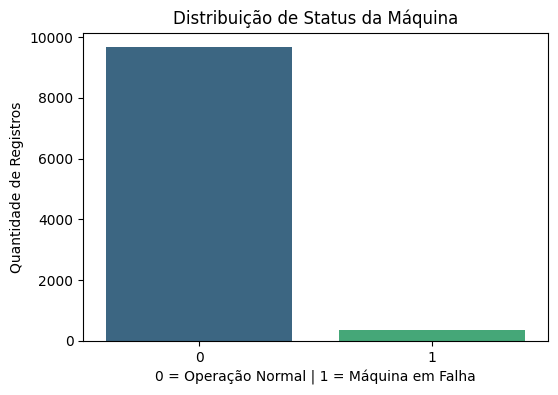


Total de falhas registradas: 339 de 10000 máquinas.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Checar se existem valores nulos (sujeira) nos dados
print("Valores nulos por coluna:\n", df.isnull().sum())

# 2. Gerar o gráfico para ver o desbalanceamento das falhas
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df, palette='viridis')
plt.title('Distribuição de Status da Máquina')
plt.xlabel('0 = Operação Normal | 1 = Máquina em Falha')
plt.ylabel('Quantidade de Registros')
plt.show()

# 3. Contagem exata
total_falhas = df['Machine failure'].sum()
print(f"\nTotal de falhas registradas: {total_falhas} de {len(df)} máquinas.")

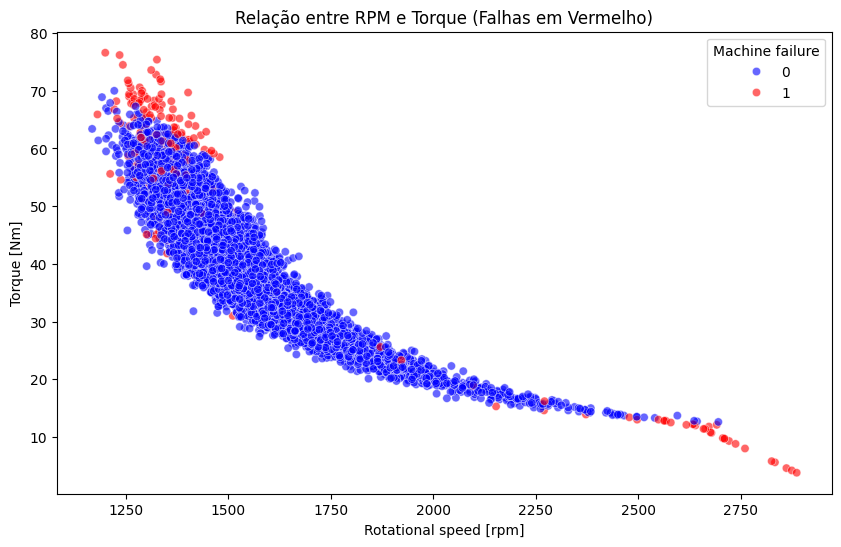

In [3]:
plt.figure(figsize=(10, 6))
# Vamos usar um scatterplot e colorir pela coluna 'Machine failure'
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', data=df, alpha=0.6, palette={0: 'blue', 1: 'red'})
plt.title('Relação entre RPM e Torque (Falhas em Vermelho)')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# 1. Removendo colunas de identificação (não ajudam a prever nada)
df_ml = df.drop(['UDI', 'Product ID'], axis=1)

# 2. Transformando a qualidade da máquina (Type) de letras para números
# L (Low) = 0, M (Medium) = 1, H (High) = 2
df_ml['Type'] = df_ml['Type'].map({'L': 0, 'M': 1, 'H': 2})

# 3. Separando as variáveis dos sensores (X) do nosso alvo de previsão (y)
# Tiramos a 'Machine failure' e os códigos de erro detalhados do X
X = df_ml.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df_ml['Machine failure']

# 4. Dividindo: 80% para Treino e 20% para Teste
# O 'stratify=y' garante que a proporção de máquinas quebradas seja igual no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Quantidade de máquinas para TREINAR a IA: {X_train.shape[0]}")
print(f"Quantidade de máquinas para TESTAR a IA: {X_test.shape[0]}")
display(X.head())

Quantidade de máquinas para TREINAR a IA: 8000
Quantidade de máquinas para TESTAR a IA: 2000


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,1,298.1,308.6,1551,42.8,0
1,0,298.2,308.7,1408,46.3,3
2,0,298.1,308.5,1498,49.4,5
3,0,298.2,308.6,1433,39.5,7
4,0,298.2,308.7,1408,40.0,9
